# Gate Detection

In [1]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

We load the folder containing the test images and display one of them.

Found 105 images in ..\myassignement\frames


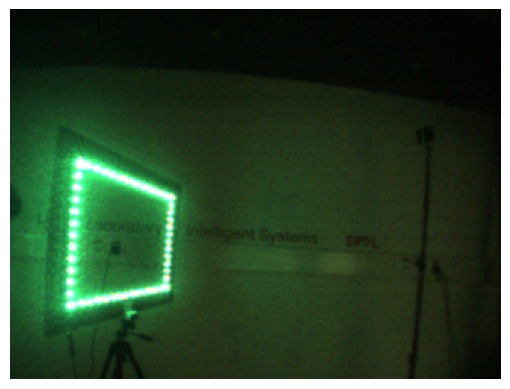

In [2]:
img_folder = Path('../myassignement/frames')
imgs = list(img_folder.glob('*.jpg'))+list(img_folder.glob('*.png'))
print(f"Found {len(imgs)} images in {img_folder}")

def visualize_image(img: Path, points: list[tuple[int, int]] = [], mask: np.ndarray | None = None, mask_alpha: float = 0.5, show: bool = False)-> np.ndarray:
    """
        Returns an image with optional points and mask.
        Args:
            img: Path to the image file.
            points: List of (x, y) coordinates to be plotted on the image.
            mask: Optional binary mask to overlay on the image.

        Returns:
            An image with the points and mask overlayed.


    """
    img = cv2.imread(str(img))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for point in points:
        cv2.circle(img, point, radius=5, color=(0, 255, 0), thickness=-1)  # Green points

    if mask is not None:
        colored_mask = np.zeros_like(img)
        colored_mask[mask > 0] = [255, 0, 0]  # Red color for the mask
        img = cv2.addWeighted(img, 1 - mask_alpha, colored_mask, mask_alpha, 0)

    if show:
        plt.imshow(img)
        plt.axis('off')
        plt.show()

    return img

# Example usage:
img=visualize_image(imgs[0], show=True)

## Image processing

(np.float64(-0.5), np.float64(323.5), np.float64(243.5), np.float64(-0.5))

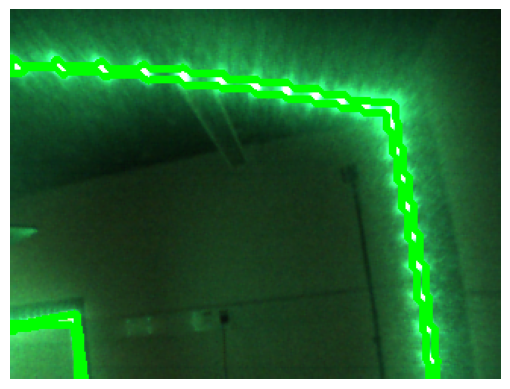

In [3]:
idx = -5
sample_img = cv2.imread(str(imgs[idx]))



# we apply, in hsv space a color filter to detect the green gate

green_lower = np.array([0, 0, 200])
green_upper = np.array([255, 100, 255])

def get_gate_mask(img, green_lower, green_upper):
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(img_hsv, green_lower, green_upper)
    kernel = np.ones((20, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    kernel = np.ones((5, 20), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask
mask = get_gate_mask(sample_img, green_lower, green_upper)

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# plot the contours on the original image
img_with_contours = sample_img.copy()
cv2.drawContours(img_with_contours, contours, -1, (0, 255, 0), 3)
plt.imshow(cv2.cvtColor(img_with_contours, cv2.COLOR_BGR2RGB))
plt.axis('off')

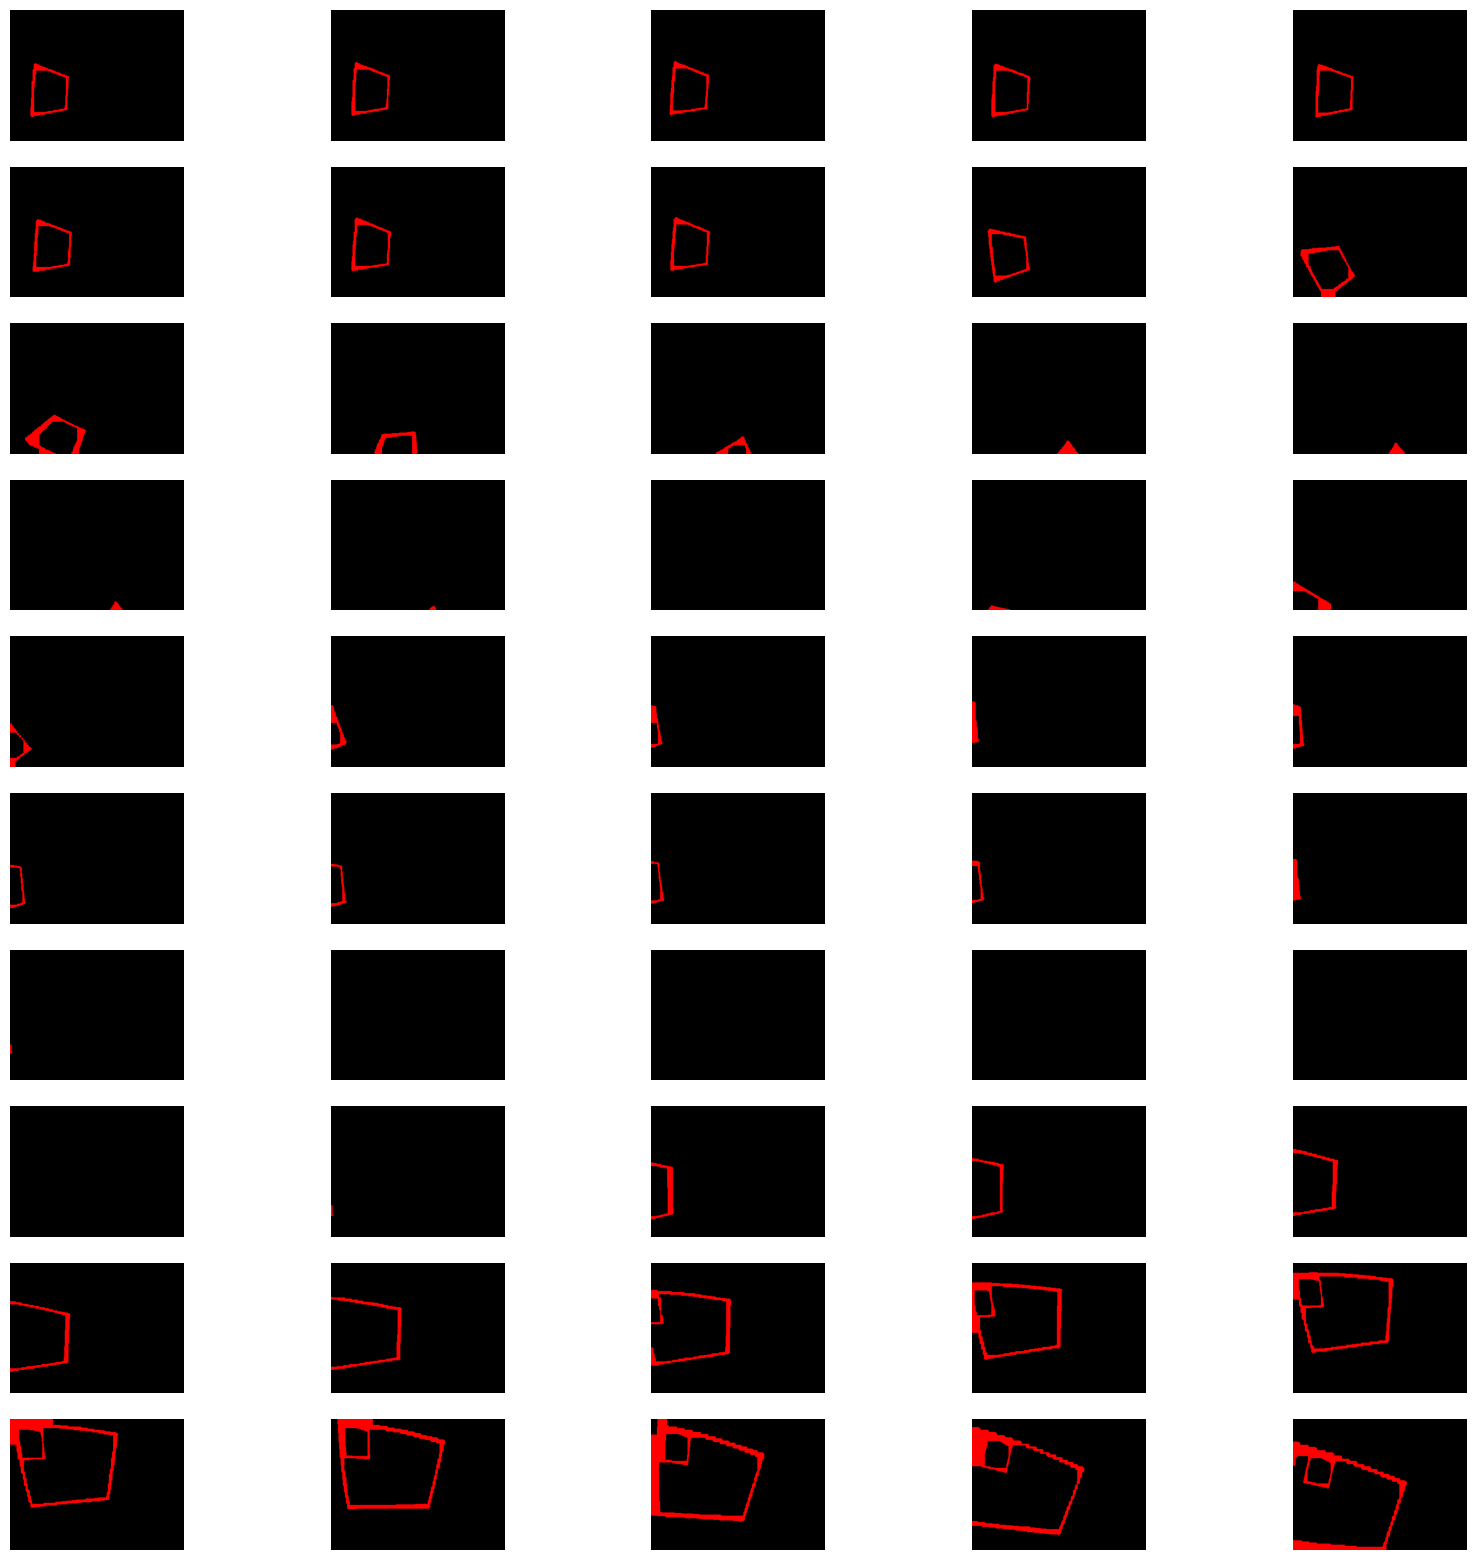

In [4]:
# make 5 wide, 10 down image grid
fig, ax = plt.subplots(10, 5, figsize=(20, 20))
green_lower = np.array([0, 0, 200])
green_upper = np.array([255, 100, 255])

for i in range(10):
    for j in range(5):
        idx = i * 5 + j
        if idx < len(imgs):
            mask = get_gate_mask(cv2.imread(str(imgs[idx])), green_lower, green_upper)
            # show just the mask
            img = visualize_image(imgs[idx], mask=mask, mask_alpha=1.0, show=False)
            ax[i, j].imshow(img)
            ax[i, j].axis('off')
        else:
            ax[i, j].axis('off')

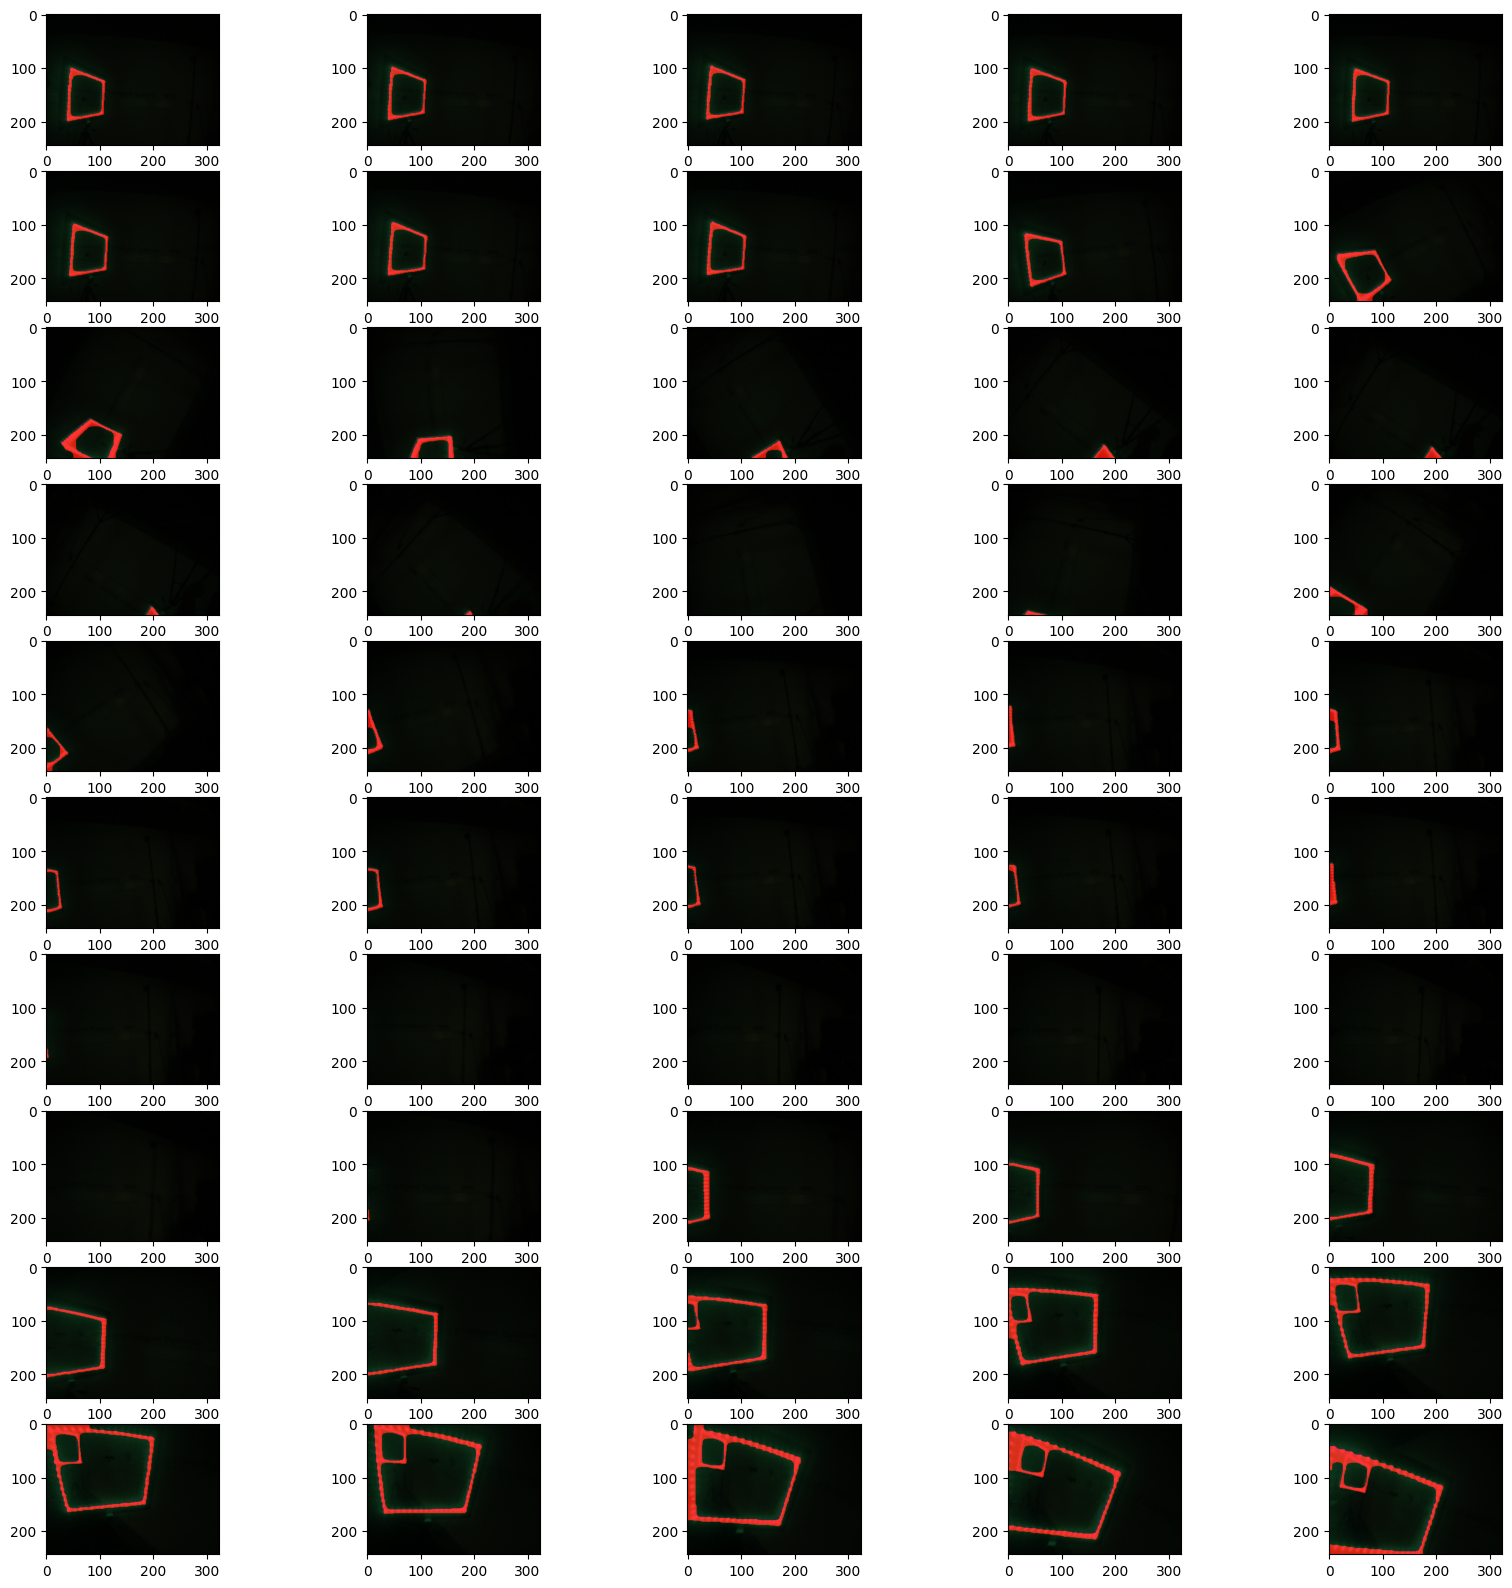

In [ ]:
# make 5 wide, 10 down image grid
fig, ax = plt.subplots(10, 5, figsize=(20, 20))
green_lower = np.array([0, 0, 200])
green_upper = np.array([255, 100, 255])

for i in range(10):
    for j in range(5):
        idx = i * 5 + j
        if idx < len(imgs):
            mask = get_gate_mask(cv2.imread(str(imgs[idx])), green_lower, green_upper)
            # apply morphological operations to join nearby blobs
            kernel = np.ones((20, 5), np.uint8)
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
            kernel = np.ones((5, 20), np.uint8)
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
            # to rmeove ragged edges, we apply a circular close
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

            img = visualize_image(imgs[idx], mask=mask, mask_alpha=0.80, show=False)
            ax[i, j].imshow(img)
        else:
            ax[i, j].axis('off')

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
img = cv2.imread(str(imgs[idx]))
mask = get_gate_mask(img, green_lower, green_upper)
# 1. Get the standard contours on the THICK mask (not the skeleton)
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img = np.zeros_like(cv2.imread(str(imgs[idx])))
smooth_contours = []

for cnt in contours:
    # We need a minimum number of points to fit a curve
    if len(cnt) > 10:
        # 2. Extract X and Y coordinates
        x = cnt[:, 0, 0]
        y = cnt[:, 0, 1]

        # 3. Fit a B-spline curve to the points
        # 's' is the smoothness factor.
        # Higher 's' = smoother curve (ignores pixel jaggedness more)
        # Lower 's' = closer to the original jagged pixels
        tck, u = splprep([x, y], s=50.0, per=True)

        # 4. Evaluate the spline at a high resolution to create smooth line points
        u_new = np.linspace(u.min(), u.max(), 1000)
        x_new, y_new = splev(u_new, tck)

        # 5. Format the points back into an OpenCV contour array
        smooth_points = np.int32(np.column_stack((x_new, y_new)))
        smooth_contours.append(smooth_points)

        # Draw the perfectly smooth mathematical curve
        cv2.polylines(img, [smooth_points], isClosed=True, color=(0, 255, 0), thickness=1)

# Now, run your corner detection on this new, mathematically smooth drawing
gray_smooth = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
corners = cv2.goodFeaturesToTrack(gray_smooth, maxCorners=30, qualityLevel=0.01, minDistance=20)

if corners is not None:
    corners = np.int32(corners)
    for corn in corners:
        cx, cy = corn.ravel()
        cv2.circle(img, (cx, cy), radius=5, color=(0, 0, 255), thickness=-1)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')